# Case Study: Data-driven Simulation 

In [2]:
import pymanopt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100          
import os
from flag import *
from utils import *
np.random.seed(42)
SAVE_FOLDER = "data_driven_prediction_experiment"
os.makedirs(SAVE_FOLDER, exist_ok=True)

T_SIM = 300
T_SWITCH = 100
T_INI = 4
T_F = 4
L = T_INI + T_F
m = 1
n = 1

def system1(y1, y0, u1, u0):
    a1, a2 = 0.3, -0.02
    b0, b1 = 0.6, 0.2
    y = a1*y1 + a2*y0 + b0*u1 + b1*u0

    return np.asarray(y).reshape(-1)[0]

def system2(y2, y1, y0, u2, u1, u0):
    a1, a2, a3 = 1.5, -0.74, 0.12
    b0, b1, b2 = 0.6, 0.2, 0.05
    y = a1*y2 + a2*y1 + a3*y0 + b0*u2 + b1*u1 + b2*u0

    return np.asarray(y).reshape(-1)[0]

def get_scaled_noise(nsr, y, noise):
    noise_norm = np.linalg.norm(noise)
    return nsr * np.linalg.norm(y) * noise / (noise_norm + 1e-10)

def data_collection(system, num_data):
    u = np.random.randn(num_data)
    y = np.zeros(num_data + 1)
    if system == system1:
        for t in range(2, num_data):
            y[t] = system1(y[t-1], y[t-2], u[t-1], u[t-2])
    elif system == system2:
        for t in range(3, num_data):
            y[t] = system2(y[t-1], y[t-2], y[t-3], u[t-1], u[t-2], u[t-3])

    return u.reshape(m, num_data), y.reshape(n, num_data+1)

def data2hankel(data, hankel_depth):
    dim, num_data_pts = np.shape(data)
    hankel = np.zeros((dim * hankel_depth, num_data_pts - hankel_depth + 1))
    for i in range(hankel_depth):
        hankel[dim * i:dim * (i + 1), :] = data[:, i:num_data_pts - hankel_depth + i + 1]

    return hankel

def get_hankel_data(system, num_data, nsr, noise):
    """ process input and output data, stack them into a Hankel matrix """
    u, y = data_collection(system, num_data)
    y = y[:, :-1]
    # add measurement noise
    for j in range(np.shape(y)[1]):
        y[:, j] = y[:, j] + get_scaled_noise(nsr, y[:, j], noise[:, j])

    hankel_u = data2hankel(u, L)
    hankel_y = data2hankel(y, L)
    hankel_io = np.vstack((hankel_u, hankel_y))

    return [u, y, hankel_io]

### Subspace predictor
Favoreel, Wouter, Bart De Moor, and Michel Gevers. "SPC: Subspace predictive control." IFAC Proceedings Volumes 32.2 (1999): 4004-4009.


In [3]:
def predict_from_subspace(subspace, u_ini, y_ini, u_f):
    """ 
    subspace predictor 
    see Favoreel, Wouter, Bart De Moor, and Michel Gevers. 
    "SPC: Subspace predictive control." IFAC Proceedings Volumes 32.2 (1999): 4004-4009
    """
    U_ini = subspace[0: m * T_INI, :]
    U_future = subspace[m * T_INI: m * T_INI + m * T_F, :]
    Y_ini = subspace[m * T_INI + m * T_F : (m + n) * T_INI + m * T_F, :]
    Y_future = subspace[(m + n) * T_INI + m * T_F:, :]
    A = np.vstack([U_ini, Y_ini, U_future])   
    rhs = np.vstack([u_ini, y_ini, u_f])                           
    y_predict = Y_future @ np.linalg.pinv(A) @ rhs
    y_predict = y_predict[:n, :]
    
    return y_predict

def predict_from_ensemble_subspace(signature, subspace, u_ini, y_ini, u_f):
    """ 
    When signature has only one element (Grassmannian case), 
    the function is equivalent to predict_from_subspace()
    """
    dims = [signature[0]] if len(signature) == 1 else range(signature[0], signature[-1] + 1)
    y_predict_ensemble = []
    for dim in dims:
        subspace = subspace[:, :dim]
        U_ini = subspace[0: m * T_INI, :]
        U_future = subspace[m * T_INI: m * T_INI + m * T_F, :]
        Y_ini = subspace[m * T_INI + m * T_F : (m + n) * T_INI + m * T_F, :]
        Y_future = subspace[(m + n) * T_INI + m * T_F:, :]
        A = np.vstack([U_ini, Y_ini, U_future])   
        rhs = np.vstack([u_ini, y_ini, u_f])                       
        y_predict = Y_future @ np.linalg.pinv(A) @ rhs
        y_predict_ensemble.append(y_predict[:n, :])

    avg_y_predict = np.mean(y_predict_ensemble, axis=0)

    return avg_y_predict

### Tracking and Identification Algorithms
- FRONT
- GREAT (Sasfi, András, et al. "GREAT: Grassmannian REcursive Algorithm for Tracking & Online System Identification" arXiv preprint arXiv:2412.09052 (2025).) Recall that FRONT is equivalent to GREAT if the flag is of form Flag(p, (q)).
- N4SID (Van Overschee, Peter, and Bart De Moor. "N4SID: Subspace algorithms for the identification of combined deterministic-stochastic systems." Automatica 30.1 (1994): 75-93.)
- Recursive4SID (Oku, Hiroshi, and Hidenori Kimura. "Recursive 4SID algorithms using gradient type subspace tracking." Automatica 38.6 (2002): 1035-1043.)
- PAST (Yang, Bin. "Projection approximation subspace tracking." IEEE Transactions on Signal processing 43.1 (1995): 95-107.)

Note that we integrate the prediction part into `N4SID()`.

In [4]:
def flag_online_update(flag, data_window, U_current, num_steps=5):
    signature = flag._signature
    @pymanopt.function.autograd(flag)
    def cost(point):
        ambient_dim = np.shape(point)[0]
        flag_trick = np.zeros((ambient_dim, ambient_dim))
        for q_k in signature:
            flag_trick += 1 / len(signature) * point[:, :q_k] @ point[:, :q_k].T
        return np.sum(np.linalg.norm(data_window - flag_trick @ data_window, ord='fro'))

    problem = pymanopt.Problem(flag, cost)
    optimizer_fl = pymanopt.optimizers.SteepestDescent(
        verbosity=0, max_iterations=num_steps
    )
    result_fl = optimizer_fl.run(problem, initial_point=U_current)
    U_next = result_fl.point

    return U_next

def PAST(data_window, U_current, lam=0.98, eps=1e-4, reorth=True):
    W = data_window
    U = np.array(U_current, dtype=float, copy=True)
    p, T = W.shape
    pU, d = U.shape
    P = (1.0 / eps) * np.eye(d)  # simple, robust init
    lam_inv = 1.0 / lam
    for t in range(T):
        w = W[:, t]                       
        y = U.T @ w                       
        Py = P @ y
        den = lam + y @ Py
        k = Py / den
        e = w - U @ y
        U += np.outer(e, k)
        P = lam_inv * (P - np.outer(k, Py))

    if reorth:
        # Orthonormalize to keep numerical drift under control
        U, _ = np.linalg.qr(U, mode='reduced')

    return U

from nfoursid.kalman import Kalman
from nfoursid.nfoursid import NFourSID
from nfoursid.state_space import StateSpace
def n4sid_predict_from_window(data_window, u_f, r=3):
    # ---- 0) Partition window (unchanged) ----
    U_ini    = data_window[0: m*T_INI, :]
    U_future = data_window[m*T_INI : m*T_INI + m*T_F, :]
    Y_ini    = data_window[m*T_INI + m*T_F : (m+n)*T_INI + m*T_F, :]
    Y_future = data_window[(m+n)*T_INI + m*T_F :, :]
    Lwin     = data_window.shape[1]
    
    Y_present = Y_future.reshape(n*T_F, Lwin, order='F')[-n:, :].T  
    U_present = U_future.reshape(m*T_F, Lwin, order='F')[-m:, :].T  
    
    # ---- 2) Fit N4SID on the window ----
    u_cols = [f"u{i+1}" for i in range(m)]
    y_cols = [f"y{i+1}" for i in range(n)]
    df = pd.DataFrame(np.hstack([U_present, Y_present]), columns=u_cols + y_cols)
    sid = NFourSID(
        dataframe=df,
        output_columns=y_cols,
        input_columns=u_cols,
        num_block_rows=T_INI,
    )
    sid.subspace_identification()
    ss, cov = sid.system_identification(rank=r)  
    A = np.asarray(ss.a);  B = np.asarray(ss.b)
    C = np.asarray(ss.c);  D = np.asarray(ss.d)
    
    # ---- 3) Kalman filter over a short tail to get a low-variance x_t ----
    kf = Kalman(ss, cov)
    for t in range(U_present.shape[0]):
        y_t = Y_present[t, :].reshape(n, 1)   # (n,1)
        u_t = U_present[t, :].reshape(m, 1)   # (m,1)
        kf.step(y_t, u_t)               # update internal filter state
    
    if u_f.ndim == 2 and u_f.shape[0] == m:
        u1 = u_f[:, [0]]
    else:
        u1 = u_f.reshape(m, T_F, order='F')[:, [0]]

    _, _ = kf.step(None, u1)
    y_pred = kf.y_filtereds[-1]

    return y_pred

### Data-driven prediction

In [5]:
def run_prediction(algorithm, offline_data, inputs, noise, nsr, signature=None):
    """
    Arguments:
    noise: (n, T_SIM) array,
    nsr: noise-to-signal ratio,
    Returns: 
    y_true: (n,T_SIM) array, 
    y_predict: (n,T_SIM) array,

    """
    window = 20
    noise_norm = np.linalg.norm(noise)
    # ------------ process offline data ---------------
    u = offline_data[0]
    y = offline_data[1]
    hankel_io = offline_data[2]
    last_u = hankel_io[:m * L, [-1]]
    last_y = hankel_io[m * L:, [-1]]
    U_0, sigma, _ = np.linalg.svd(hankel_io, full_matrices=False)
    
    # ------------ algorithm adjustments --------------
    y_predict = np.zeros((n, T_SIM))
    if algorithm == "FRONT":
        flag = Flag(np.shape(hankel_io)[0], signature)
        V = U_0[:, :signature[-1]]    # initial flag
        
    elif algorithm == "FRONT-all":
        flag = Flag(np.shape(hankel_io)[0], signature)
        V = U_0[:, :signature[-1]]    # initial flag
        y_predict = np.zeros((n, T_SIM, signature[-1]-signature[0]+1))
        
    elif algorithm == "PAST":
        r = 10
        V = U_0[:, :r]
        pass
    # -------------------------------------------------
    # ------------ compute y(0) and y(1) --------------
    u_ini = u.reshape(-1, 1, order='F')[-m * T_INI:, :]
    y_ini = y.reshape(-1, 1, order='F')[-n * T_INI:, :]
    y_true = np.zeros((n, T_SIM))
    y_measure = np.zeros((n, T_SIM))
    y_true[:, [0]] = y_ini[-n:, :]  # already corrupted by noise in offline data
    y_measure[:, [0]] = y_true[:, [0]]  
    y_predict[:, [0]] = y_ini[-n:, :]
    
    y_m1 = y_ini[-2*n : -n, :]  # y(-1)
    u_m1 = u_ini[-m:, :]        # u(-1)
    u_f = inputs[:, 1:T_F + 1].reshape(-1, 1, order='F')
    y_predict[:, [1]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
    y_true[:, [1]] = system1(y_true[:, [0]], y_m1, inputs[:, [0]], u_m1)
    y_measure[:, [1]] = y_true[:, [1]] + get_scaled_noise(nsr, y_true[:, [1]], noise[:, [1]])
    u_ini = np.vstack([u_ini[m:, :], inputs[:, [1]]])
    y_ini = np.vstack([y_ini[n:, :], y_measure[:, [1]]])
    # -------------------------------------------------
    # ------------ initialize sample window -----------
    sample_window = np.zeros((np.shape(hankel_io)[0], window))
    last_u = np.vstack([last_u[m:, :], inputs[:, [1]]])
    last_y = np.vstack([last_y[n:, :], y_measure[:, [1]]])
    sample = np.vstack([last_u, last_y])
    sample_window[:, [0]] = sample
    
    for t in range(T_SIM - T_F - 1):
        # warm start
        if t < window - 1:
            u_f = inputs[:, t + 2 : t + 2 + T_F].reshape(-1, 1, order='F')
            y_predict[:, [t+2]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
            y_true[:, [t+2]] = system1(y_true[:, [t+1]], y_true[:, [t]], 
                                       inputs[:, [t+1]], inputs[:, [t]])
            y_measure[:, [t+2]] = y_true[:, [t+2]] + get_scaled_noise(nsr, y_true[:, [t+2]], noise[:, [t+2]])
            # -------- update u_ini, y_ini and sample window ----------
            u_ini = np.vstack([u_ini[m:, :], inputs[:, [t+2]]])
            y_ini = np.vstack([y_ini[n:, :], y_measure[:, [t+2]]])
            last_u = np.vstack([last_u[m:, :], inputs[:, [t+2]]])
            last_y = np.vstack([last_y[n:, :], y_measure[:, [t+2]]])
            sample = np.vstack([last_u, last_y])
            sample_window[:, [t+1]] = sample
            continue

        u_f = inputs[:, t + 2 : t + 2 + T_F].reshape(-1, 1, order='F')
        if algorithm == "FRONT":
            V = flag_online_update(flag, sample_window, V)
            y_predict[:, [t+2]] = predict_from_ensemble_subspace(signature, V, u_ini, y_ini, u_f)
    
        elif algorithm == "FRONT-all":
            V = flag_online_update(flag, sample_window, V)
            for idx, dim in enumerate(signature):
                y_predict[:, [t+2], idx] = predict_from_subspace(V[:, :dim], u_ini, y_ini, u_f)
            
        elif algorithm == "PAST":
            V = PAST(sample_window, V)
            y_predict[:, [t+2]] = predict_from_subspace(V, u_ini, y_ini, u_f)
        
        elif algorithm == "N4SID":
            # y_predict[:, [t+2]] = N4SID(sample_window, u_f)
            y_predict[:, [t+2]] = n4sid_predict_from_window(sample_window, u_f)

        elif algorithm == "nonlearning":
            y_predict[:, [t+2]] = predict_from_subspace(hankel_io, u_ini, y_ini, u_f)
            
        if t < T_SWITCH:
            y_true[:, [t+2]] = system1(y_true[:, [t+1]], y_true[:, [t]], 
                                       inputs[:, [t+1]], inputs[:, [t]])
        else:
            y_true[:, [t+2]] = system2(y_true[:, [t+1]], y_true[:, [t]], y_true[:, [t-1]],
                                       inputs[:, [t+1]], inputs[:, [t]], inputs[:, [t-1]])
                                       
        y_measure[:, [t+2]] = y_true[:, [t+2]] + get_scaled_noise(nsr, y_true[:, [t+2]], noise[:, [t+2]])

        # -------- update u_ini, y_ini and sample window ----------
        u_ini = np.vstack([u_ini[m:, :], inputs[:, [t+2]]])
        y_ini = np.vstack([y_ini[n:, :], y_measure[:, [t+2]]])
        last_u = np.vstack([last_u[m:, :], inputs[:, [t+2]]])
        last_y = np.vstack([last_y[n:, :], y_measure[:, [t+2]]])
        sample = np.vstack([last_u, last_y])
        sample_window = np.hstack([sample_window[:, 1:], sample])

    # error = np.linalg.norm(y_predict - y_true, axis=0)
    # cum_error = np.linalg.norm(y_predict - y_true)

    return y_predict, y_true

### Compare nested subspaces in a flag and individual Grassmannians

In [6]:
def run_fl_gr_comparison(num_trials, nsr, gd_steps):
    np.random.seed(42)
    num_offline_data = 30
    start_dim = L
    end_dim = (m+n) * L
    signature_fl = tuple(range(start_dim, end_dim))    # e.g., (8, ..., 15)
    num_models = len(signature_fl)
    
    cum_err_fl_trials = np.zeros((num_trials, num_models))
    cum_err_gr_trials = np.zeros((num_trials, num_models))
    pred_error_trials = np.zeros((num_trials, num_models, T_SIM))

    for trial in range(num_trials):
        noise_offline = np.random.randn(n, num_offline_data)
        offline_data = get_hankel_data(system1, num_offline_data, nsr, noise_offline)
        noise_online = np.random.randn(n, T_SIM)
        inputs = np.random.randn(n, T_SIM)
        y_predict_fl, y_true = run_prediction("FRONT-all", offline_data, inputs, noise_online, nsr, signature_fl)
        y_predict_gr = np.zeros((n, T_SIM, end_dim-start_dim))
        for idx, dim in enumerate(signature_fl):
            y_predict_gr[:, :, idx], _ = run_prediction("FRONT", offline_data, inputs, noise_online, nsr, (dim,))

        # ------- compute cumulative prediction error -------
        diff_fl = y_predict_fl - y_true[:, :, None]
        diff_gr = y_predict_gr - y_true[:, :, None]
        pred_error_trials[trial, :, :] = np.linalg.norm(diff_fl, axis=0).T 
        cum_err_fl_trials[trial, :] = np.linalg.norm(diff_fl.reshape(n * T_SIM, num_models), axis=0)
        cum_err_gr_trials[trial, :] = np.linalg.norm(diff_gr.reshape(n * T_SIM, num_models), axis=0)

    med_pred_error_fl = np.median(pred_error_trials, axis=0)
    med_cum_err_fl = np.median(cum_err_fl_trials, axis=0)
    iqr_cum_err_fl = np.percentile(cum_err_fl_trials, 70, axis=0) - np.percentile(cum_err_fl_trials, 30, axis=0)
    med_cum_err_gr = np.median(cum_err_gr_trials, axis=0)
    iqr_cum_err_gr = np.percentile(cum_err_gr_trials, 70, axis=0) - np.percentile(cum_err_gr_trials, 30, axis=0)
    avg_cum_err_fl = cum_err_fl_trials.mean(axis=0)
    std_cum_err_fl = cum_err_fl_trials.std(axis=0)
    avg_cum_err_gr = cum_err_gr_trials.mean(axis=0)
    std_cum_err_gr = cum_err_gr_trials.std(axis=0)
    avg_std_all_err = np.column_stack(
        [list(signature_fl), avg_cum_err_fl, std_cum_err_fl, avg_cum_err_gr, std_cum_err_gr])
    med_iqr_all_err = np.column_stack([
        np.asarray(signature_fl, dtype=int), med_cum_err_fl, iqr_cum_err_fl, med_cum_err_gr, iqr_cum_err_gr])
    save_data(avg_std_all_err, f"flag_vs_gr_avg", SAVE_FOLDER)
    save_data(med_iqr_all_err, f"flag_vs_gr_median", SAVE_FOLDER)
    save_data(med_pred_error_fl, f"pred_error_flag_subspace", SAVE_FOLDER)
    
    def plot_pred_errors_median():
        fig, ax = plt.subplots(figsize=(7, 3))
        time = np.arange(T_SIM)
        selected_dims = [9, 10, 11]
        selected_idx = [signature_fl.index(d) for d in selected_dims if d in signature_fl]
        for idx in selected_idx:
            ax.plot(time, med_pred_error_fl[idx, :], linewidth=2, 
                    label=f"dimension {signature_fl[idx]} subspace in flag")

        ax.set_xlabel("Time step $t$")
        ax.set_ylabel("Median Prediction Error")
        ax.set_title("Median Prediction Error Across Time")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(frameon=False, fontsize=9)
        plt.tight_layout()
        plt.show()
        
    plot_pred_errors_median()
    
    return None

### Compare prediction performance among all methods: 
- No learning
- N4SID
- PAST
- Flag(16, (9, 10))
- Gr(16, 9)
- Gr(16, 10)
- Gr(16, 11)
- Flag(16, (8, ..., 15))

In [7]:
def run_alg_comparison(signature, num_trials, nsr, plot='False',
                       inputs_trials=None, noise_offline_trials=None, noise_online_trials=None):
    save_folder = "data_driven_prediction_experiment"
    os.makedirs(save_folder, exist_ok=True)
    np.random.seed(42)
    model_specs = [
        ("No learning",       {"algorithm": "nonlearning",      "signature": None}),
        ("N4SID",             {"algorithm": "N4SID",            "signature": None}),
        ("PAST",              {"algorithm": "PAST",             "signature": None}),
        (f"Flag{signature}",  {"algorithm": "FRONT",            "signature": signature}),
        ("Gr(9)",             {"algorithm": "FRONT",            "signature": (9,)}),
        ("Gr(10)",            {"algorithm": "FRONT",            "signature": (10,)}),
        ("Gr(11)",            {"algorithm": "FRONT",            "signature": (11,)}),
        ("Flag(8,...,15)",    {"algorithm": "FRONT",            "signature": tuple(range(8, 16))}),
    ]
    model_names = [name for name, _ in model_specs]
    num_models  = len(model_specs)
    cum_errors = np.zeros((num_trials, num_models), dtype=float)
    pred_errors = np.zeros((num_trials, num_models, T_SIM), dtype=float)
    def cum_error(y_pred, y_true):
        return float(np.linalg.norm(y_pred - y_true))

    last_preds = {}    # store trajectories from last trial for plot
    num_offline_data = 30
    y_pred_all_models = {name: np.zeros((num_trials, T_SIM)) for name in model_names}
    y_true_all_trials = np.zeros((num_trials, T_SIM))

    for t in range(num_trials):
        if noise_offline_trials is not None:
            noise_offline = noise_offline_trials[t]
        else:
            noise_offline = np.random.randn(n, num_offline_data)
        if inputs_trials is not None:
            inputs = inputs_trials[t]
        else:
            inputs = np.random.randn(n, T_SIM)
        if noise_online_trials is not None:
            noise_online = noise_online_trials[t]
        else:
            noise_online = np.random.randn(n, T_SIM)

        name0, spec0 = model_specs[0]
        offline_data = get_hankel_data(system1, num_offline_data, nsr, noise_offline)
        y_nl, y_true = run_prediction("nonlearning", offline_data, inputs, noise_online, nsr)
        y_true_all_trials[t, :] = y_true.ravel()
        # save_data(y_true.T, f"y_true", save_folder)
        y_pred_all_models[name0][t, :] = y_nl.ravel()
        pred_errors[t, 0, :] = np.linalg.norm(y_nl - y_true, axis=0)
        cum_errors[t, 0] = cum_error(y_nl, y_true)
            
        for j in range(1, num_models):
            name, spec = model_specs[j]
            y_pred, _ = run_prediction(spec["algorithm"], offline_data, inputs, noise_online, nsr, spec["signature"])
            y_pred_all_models[name][t, :] = y_pred.ravel()
            pred_errors[t, j, :] = np.linalg.norm(y_pred - y_true, axis=0)
            cum_errors[t, j] = cum_error(y_pred, y_true)
        
    # ------------ save median predicted trajectories -----------
    def median_trial_idx(vals):
        med = np.median(vals)
        return int(np.argmin(np.abs(vals - med)))
    
    median_idx_by_model = {
        name: median_trial_idx(cum_errors[:, j])
        for j, name in enumerate(model_names)
    }

    for j, name in enumerate(model_names):
        idx = median_idx_by_model[name]
        save_data(y_pred_all_models[name][idx, :].reshape(-1, 1), 
                  f"y_pred_{name}", save_folder)
        save_data(y_true_all_trials[idx, :].reshape(-1, 1),
                  f"y_true_at_{name}", save_folder)
        if plot == 'True':
            plot_trajectories(y_true_all_trials[idx, :], y_pred_all_models[name][idx], f"{name}")
    
    # ---------------- compute mean and median ------------------
    avg_pred_errors = pred_errors.mean(axis=0)
    std_pred_errors = pred_errors.std(axis=0)
    med_cum_errors = np.median(cum_errors, axis=0)
    q30_cum_errors = np.percentile(cum_errors, 30, axis=0)
    q70_cum_errors = np.percentile(cum_errors, 70, axis=0)
    med_pct_cum_errors = np.column_stack([med_cum_errors, q30_cum_errors, q70_cum_errors])
    save_data(med_pct_cum_errors, f"med_pct_cum_errors", save_folder)
    
    avg_cum_errors = cum_errors.mean(axis=0)
    std_cum_errors = cum_errors.std(axis=0)
    avg_std_cum_errors = np.column_stack([avg_cum_errors, std_cum_errors])
    save_data(avg_std_cum_errors, f"avg_std_cum_errors", save_folder)

    # ---------------- save prediction errors (not cumulative) ----------------
    pred_error_data = {"t": np.arange(T_SIM)}
    for j, name in enumerate(model_names):
        pred_error_data[f"med_{name}"] = np.median(pred_errors[:, j, :], axis=0)
        pred_error_data[f"q30_{name}"] = np.percentile(pred_errors[:, j, :], 30, axis=0)
        pred_error_data[f"q70_{name}"] = np.percentile(pred_errors[:, j, :], 70, axis=0)
        
    pred_error_df = pd.DataFrame(pred_error_data)
    pred_error_df.to_csv(f"{save_folder}/pred_errors.csv", index=False)
        
    return med_pct_cum_errors

### Compare prediction preformance of all models in different noise-to-signal ratio

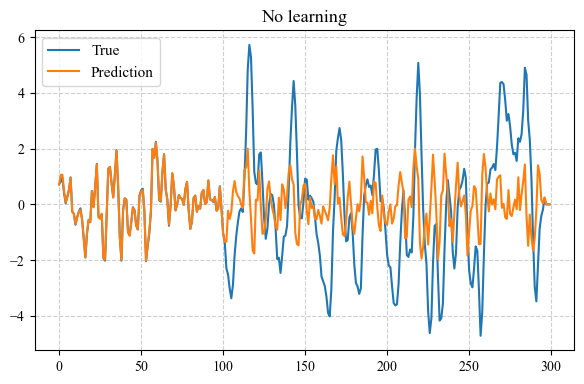

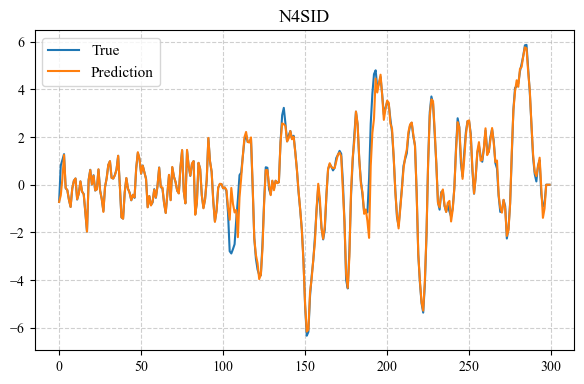

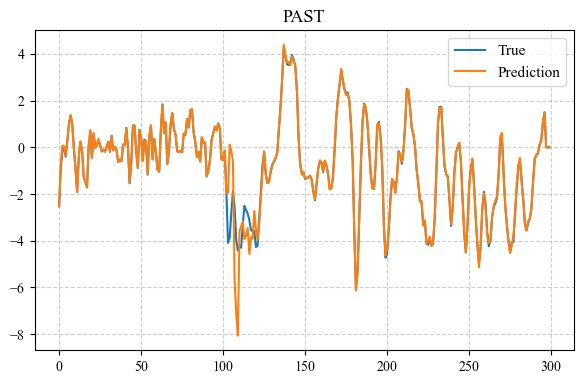

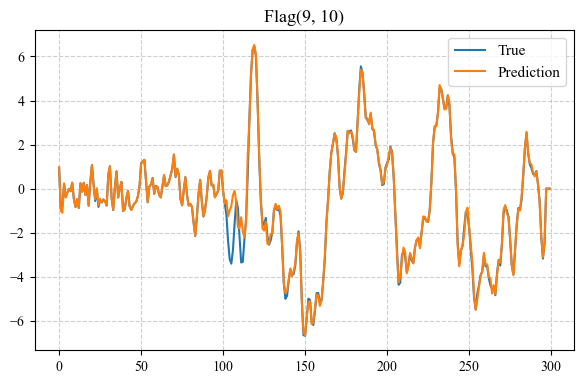

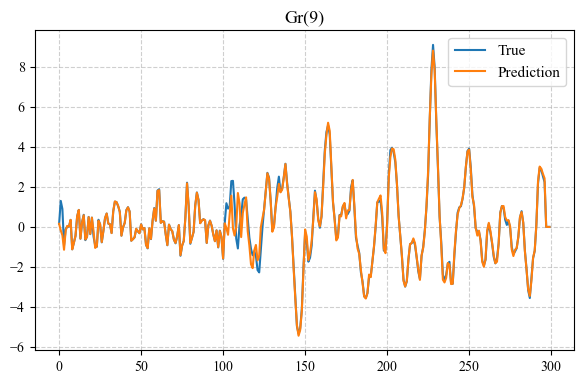

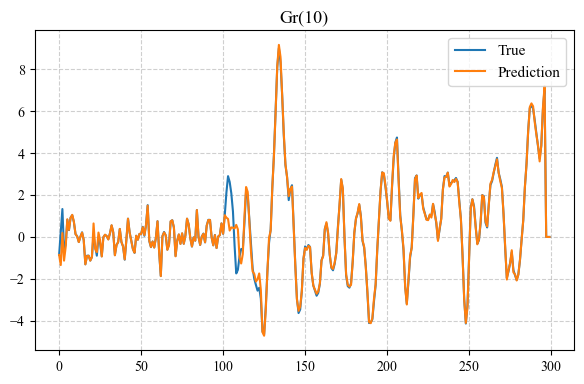

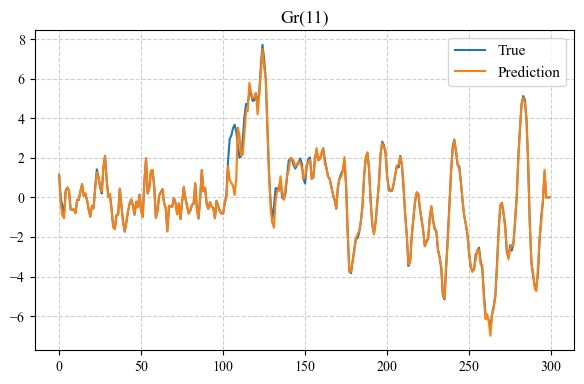

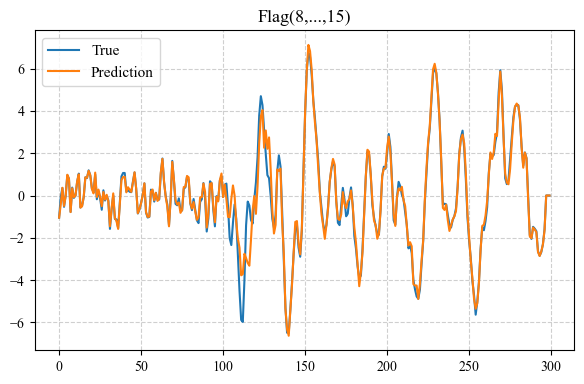

Cleaned data saved to: data_driven_prediction_experiment/cleaned_pred_errors.csv


In [8]:
def run_cpe_nsr_comparison(num_trials):
    """
    compare cumulative prediction errors of all models under different SNR levels
    """
    num_offline_data = 30
    nsr_levels = [0.01, 0.02, 0.05, 0.1, 0.2]
    rng = np.random.default_rng(42)
    inputs_trials = rng.standard_normal((num_trials, n, T_SIM))
    noise_online_trials = rng.standard_normal((num_trials, n, T_SIM))
    noise_offline_trials = rng.standard_normal((num_trials, n, num_offline_data))

    signature = (9, 10)
    model_names = [
        "No learning",
        "N4SID",
        "PAST",
        f"Flag{signature}",   
        "Gr(9)",
        "Gr(10)",
        "Gr(11)",
        "Flag(8,...,15)",
    ]
    all_med_pct = []
    for nsr in nsr_levels:
        med_pct = run_alg_comparison(signature, num_trials, nsr, 'False',
                                    inputs_trials, noise_offline_trials, noise_online_trials)
        all_med_pct.append(med_pct)

    med_pct_tensor = np.stack(all_med_pct, axis=0)  # num_nsr x num_models x 3
    
    # flatten per row: [median, q30, q70] for each model, for each nsr
    rows = []
    for i, nsr in enumerate(nsr_levels):
        row = [nsr]
        for j in range(len(model_names)):
            row.extend(med_pct_tensor[i, j, :].tolist())
        rows.append(row)

    # Build column names: model, model q30, model q70
    cols = ["NSR"]
    for name in model_names:
        cols += [name, f"{name} q30", f"{name} q70"]

    nsr_df = pd.DataFrame(rows, columns=cols)
    csv_path = os.path.join(SAVE_FOLDER, "nsr_cpe_med_pct.csv")
    nsr_df.to_csv(csv_path, index=False)
    print(f"Saved NSR comparison data to {csv_path}")

    return None

def process_data():
    """
    trim pred_errors.csv since we only predict T_SIM - T_F = 296 outputs
    """
    file_path = "data_driven_prediction_experiment/pred_errors.csv"
    df = pd.read_csv(file_path, header=None)
    df = df.iloc[:T_SIM - T_F, :]
    save_path = "data_driven_prediction_experiment/cleaned_pred_errors.csv"
    df.to_csv(save_path, index=False, header=False)
    print(f"Cleaned data saved to: {save_path}")

if __name__ == "__main__":
    num_trials = 100
    # run_fl_gr_comparison(num_trials, 0.02, 5)
    run_alg_comparison((9, 10), num_trials, 0.02, 'True')
    # plot trajectories for NSR=0.02
    # plot_flag_vs_gr(f"{SAVE_FOLDER}/flag_vs_gr_median.csv") 
    # run_cpe_nsr_comparison(num_trials)
    # plot_nsr_cpe_comparison(f"{SAVE_FOLDER}/nsr_cpe_med_pct.csv", exclude=())
    # plot_nsr_cpe_comparison(f"{SAVE_FOLDER}/nsr_cpe_med_pct.csv")
    process_data()